In [2]:
## Electric vehicle brand analysis:

- This dataset provides detailed analytics on electric vehicles (EVs) across various brands, years, and regions. It contains both technical specifications and performance indicators, as well as cost and usage metrics, making it suitable for trend analysis, performance benchmarking, and predictive modeling in the electric vehicle domain.

## Columns: 

- Brand: The manufacturer of the electric vehicle (e.g., Tesla, Nissan, BMW).
- Year: Year of manufacturing of the EV.
- Region: Market/region where the vehicle is used (e.g., Australia).
- Vehicle_Type: Category of the vehicle (e.g., Sedan, Hatchback, SUV, Truck).
- Battery_Capacity_kWh: Total battery capacity in kilowatt-hours (kWh).
- Battery_Health_%: Current health of the battery, expressed as a percentage of its original capacity.
- Charging_Power_kW: Maximum charging power supported by the vehicle.
- Charging_Time_hr: Time required to fully charge the vehicle battery.
- Range_km: Maximum driving range on a full charge (in kilometers).
- Energy_Consumption_kWh_per_100km: Energy consumption efficiency per 100 kilometers.
- Mileage_km: Total distance the vehicle has traveled.
- Avg_Speed_kmh: Average speed of the vehicle.
- Top speed: Maximum speed capability (km/h).
- Acceleration_0_100_kmh_sec: Time taken to accelerate from 0 to 100 km/h (in seconds).
- Electricity_Cost_USD_per_kWh: Cost of electricity per unit used for charging.
- Insurance_Cost_USD: Estimated yearly insurance cost.
- Maintenance_Cost_USD: Estimated yearly maintenance cost.
- Monthly_Charging_Cost_USD: Average monthly charging expenses.
- Resale_Value_USD: Estimated resale value of the vehicle.
- Temperature_C: Operating/environmental temperature.
- Usage_Type: Type of use (e.g., personal, commercial).

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as psql

In [7]:
df = pd.read_excel('electric_vehicle_analytics.xlsx')

In [8]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Max_Speed_kmh,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,233,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,221,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,138,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,192,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,189,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,154,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,243,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,175,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,185,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Brand                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileag

## Goal 1: Battery quality of an electric vehicle brand

In [10]:
df['Average charging cost'] = df['Charging_Power_kW'] / df['Charging_Time_hr']

In [11]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD,Average charging cost
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483,187.317073
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287,582.222222
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023,206.666667
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398,677.200000
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033,494.883721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749,148.115942
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080,217.027027
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286,7.070312
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581,105.222222


In [12]:
df['Average charging cost'] = df['Average charging cost'].round(1)

In [13]:
df

,Vehicle_ID,Brand,Year,Region,Vehicle_Type,Battery_Capacity_kWh,Battery_Health_%,Range_km,Charging_Power_kW,Charging_Time_hr,...,Acceleration_0_100_kmh_sec,Temperature_C,Usage_Type,CO2_Saved_tons,Maintenance_Cost_USD,Insurance_Cost_USD,Electricity_Cost_USD_per_kWh,Monthly_Charging_Cost_USD,Resale_Value_USD,Average charging cost
0,1,Nissan,2021,Asia,SUV,101.7,75.5,565,153.6,0.82,...,8.10,-9.0,Personal,14.13,969,843,0.30,375.55,26483,187.3
1,2,Nissan,2020,Australia,Sedan,30.1,99.8,157,157.2,0.27,...,9.83,1.6,Personal,19.41,1157,1186,0.25,532.02,11287,582.2
2,3,Hyundai,2021,North America,SUV,118.5,84.0,677,173.6,0.84,...,3.60,1.5,Fleet,29.39,291,1890,0.26,1291.68,34023,206.7
3,4,Audi,2022,Europe,Hatchback,33.1,97.3,149,169.3,0.25,...,8.97,12.5,Fleet,6.96,401,2481,0.33,234.44,14398,677.2
4,5,Tesla,2022,Australia,Truck,81.3,85.6,481,212.8,0.43,...,7.03,-3.0,Commercial,2.06,214,2336,0.10,32.61,23033,494.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2996,Mercedes,2021,North America,SUV,57.2,84.0,239,102.2,0.69,...,7.98,33.7,Personal,15.65,1645,2357,0.33,767.05,16749,148.1
2996,2997,Ford,2022,Europe,Hatchback,98.4,83.1,498,160.6,0.74,...,7.22,13.7,Fleet,1.82,289,868,0.32,75.35,30080,217.0
2997,2998,Kia,2024,Europe,Truck,35.1,82.1,189,18.1,2.56,...,4.26,5.8,Fleet,26.29,1013,695,0.32,1188.15,16286,7.1
2998,2999,Mercedes,2015,North America,Truck,69.4,98.4,336,94.7,0.90,...,9.34,-7.6,Commercial,24.95,1843,1905,0.20,780.03,19581,105.2


In [71]:
Battery = df.groupby('Brand')[['Battery_Health_%', 'Battery_Capacity_kWh', 'Monthly_Charging_Cost_USD', 'Average charging cost']].mean().round(1).reset_index()

In [73]:
Battery

,Brand,Battery_Health_%,Battery_Capacity_kWh,Monthly_Charging_Cost_USD,Average charging cost
0,Audi,84.0,75.5,390.9,271.8
1,BMW,85.3,77.6,421.6,255.3
2,Chevrolet,85.2,74.9,430.6,258.4
3,Ford,85.3,76.0,393.8,263.4
4,Hyundai,85.1,76.1,440.0,297.8
5,Kia,84.7,72.7,389.6,258.1
6,Mercedes,85.2,75.8,408.6,279.9
7,Nissan,85.1,73.4,428.9,281.5
8,Tesla,85.9,73.9,432.5,276.7
9,Volkswagen,84.3,72.1,450.7,285.5


In [106]:
Battery_health = Battery[['Brand', 'Battery_Health_%']].sort_values(by = 'Battery_Health_%', ascending = False)

In [108]:
Battery_health

,Brand,Battery_Health_%
8,Tesla,85.9
1,BMW,85.3
3,Ford,85.3
2,Chevrolet,85.2
6,Mercedes,85.2
4,Hyundai,85.1
7,Nissan,85.1
5,Kia,84.7
9,Volkswagen,84.3
0,Audi,84.0


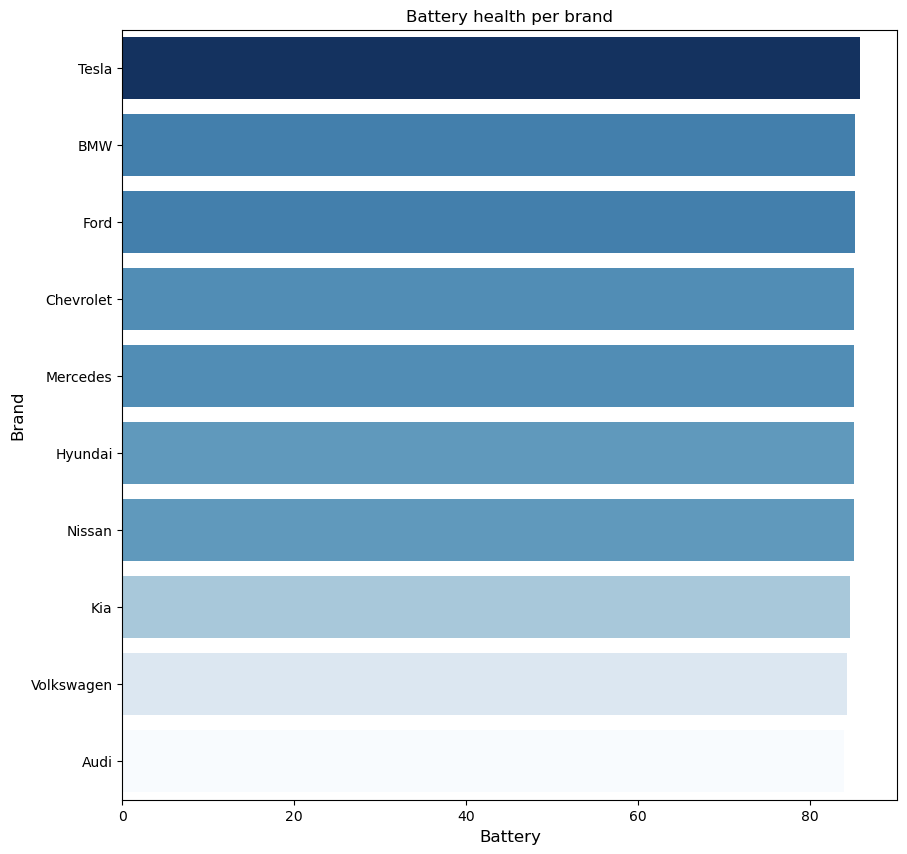

In [112]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Battery_health, y = Battery_health['Brand'], x = Battery_health['Battery_Health_%'], 
           palette = 'Blues', hue = 'Battery_Health_%')
plt.xlabel('Battery', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Battery health per brand')
plt.show()

## Insights:
- Tesla leads in having batteries with the most power, showing superior battery performance.
- followed by a close rate: BMW, Ford, Chevrolet, Mercedes, Hyundai and Nissan, indicating strong battery performance.
- followed by a lower rate: Kia, indicating weak battery performance.
- Volkswagen and Audi have the weakest car batteries.
## Conclusions: 
- Tesla is the first car brand to make electric cars a trend having the most reliable batteries.
- Most electric car brands' batteries performance are high, which show the growth of the electric car market.

## Goal 2: Battery capcity: How much power can a single battery carry?

In [115]:
Battery_capacity = Battery[['Brand', 'Battery_Capacity_kWh']].sort_values(by = 'Battery_Capacity_kWh', ascending = False)

In [117]:
Battery_capacity

,Brand,Battery_Capacity_kWh
1,BMW,77.6
4,Hyundai,76.1
3,Ford,76.0
6,Mercedes,75.8
0,Audi,75.5
2,Chevrolet,74.9
8,Tesla,73.9
7,Nissan,73.4
5,Kia,72.7
9,Volkswagen,72.1


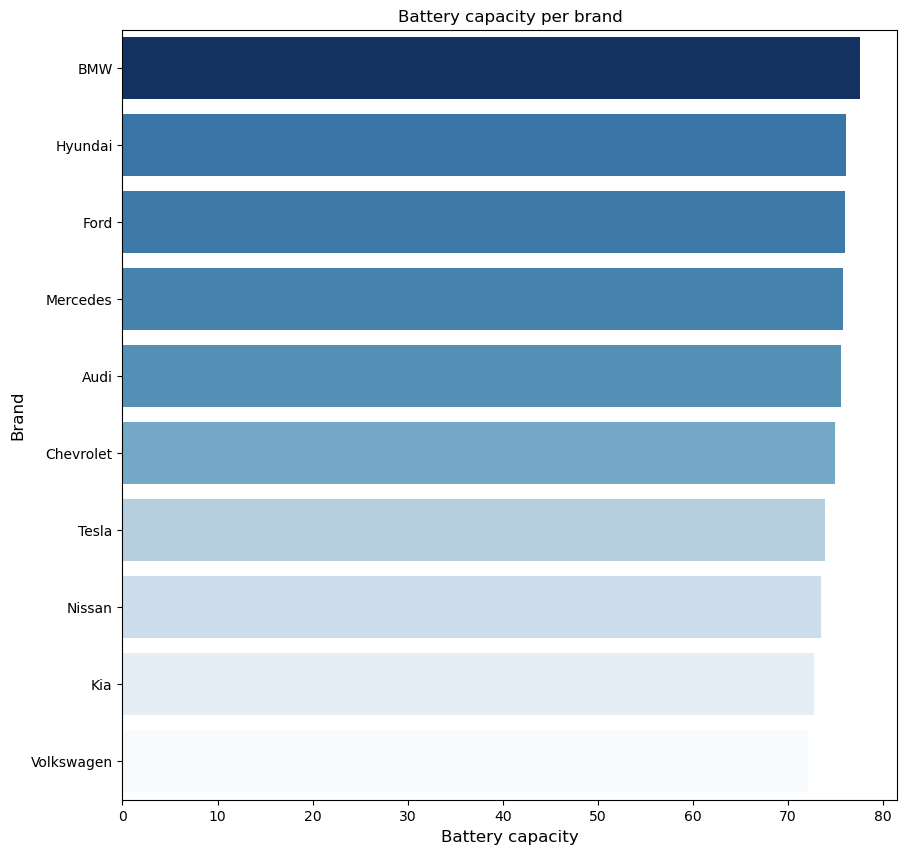

In [121]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Battery_capacity, y = Battery_capacity['Brand'], x = Battery_capacity['Battery_Capacity_kWh'], 
           palette = 'Blues', hue = 'Battery_Capacity_kWh')
plt.xlabel('Battery capacity', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Battery capacity per brand')
plt.show()

## Insights:
- BMW leads in having batteries with the most capcity, indicating big amount of battery power.
- Followed by: Hyundai, Ford, Mercedes, Audi and Chevrolet, indicating slightly big amount of battery power.
- The car brands with the lower amount of battery power are: Tesla (suprsingly) and Nissan.
- followed by: Kia and Volkswagen, which shows that they have the weakest amount of battery power.
## Conclusions:
- Although Tesla is the first electric car brand, its batteries' capacity is small compared to BMW, Hyundai, Ford, Mercedes, Audi and Chervrolet (heavy weight car brands), yet slightly big compared to Nissan, Kia and Volkswagen.
- This shows that Tesla is making prototype vehicles to test their batteries not practical ones for multiple uses.

## Goal 3: Monthly charging cost for battery

In [126]:
Monthly_Charging_Cost = Battery[['Brand', 'Monthly_Charging_Cost_USD']].sort_values(by = 'Monthly_Charging_Cost_USD', ascending = False)

In [128]:
Monthly_Charging_Cost

,Brand,Monthly_Charging_Cost_USD
9,Volkswagen,450.7
4,Hyundai,440.0
8,Tesla,432.5
2,Chevrolet,430.6
7,Nissan,428.9
1,BMW,421.6
6,Mercedes,408.6
3,Ford,393.8
0,Audi,390.9
5,Kia,389.6


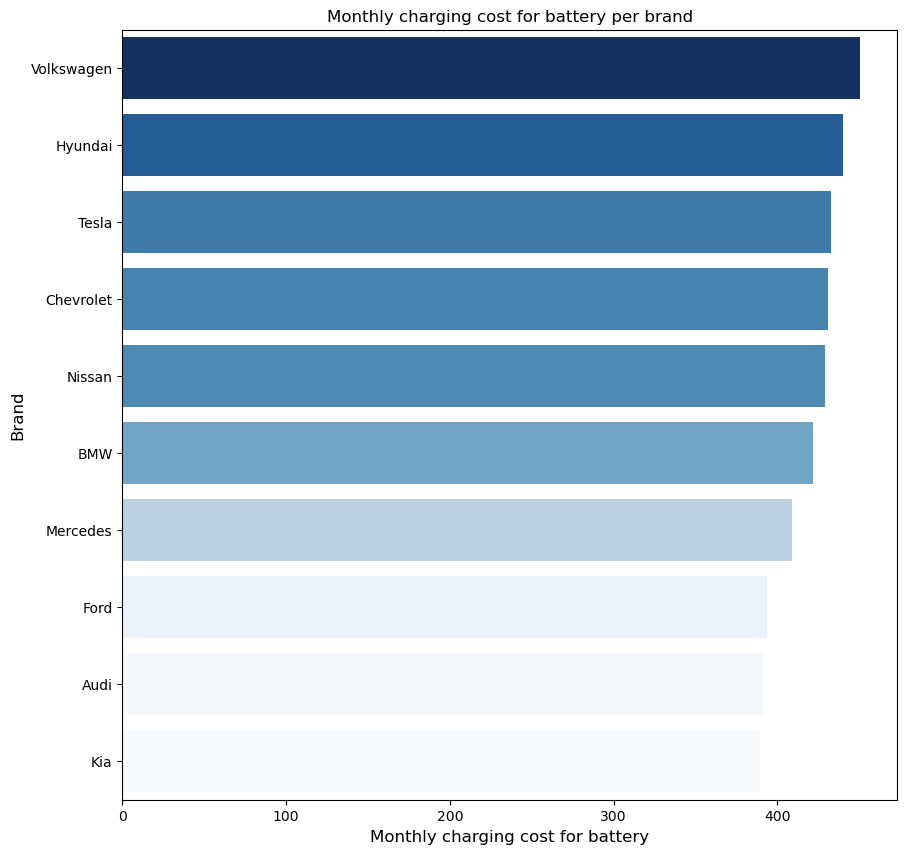

In [134]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Monthly_Charging_Cost, y = Monthly_Charging_Cost['Brand'], x = Monthly_Charging_Cost['Monthly_Charging_Cost_USD'], 
           palette = 'Blues', hue = 'Monthly_Charging_Cost_USD')
plt.xlabel('Monthly charging cost for battery', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Monthly charging cost for battery per brand')
plt.show()

## Insights:
- Volkswagen's batteries cost the most for charging power per month.
- followed by: Hyundai, Tesla, Chevrolet and Nissan, indicating slightly higher cost for charging battery power per month.
- followed slightly by: BMW , indicating lower cost for charging battery power per month but higher than Mercedes, Ford, Audi and Kia.
## Conclusions:
- Monthly charging costs vary significantly across brands, likely reflecting differences in battery size, efficiency, and electricity consumption.
- Ford, Audi and Kia provide more economical charging vehicles for everyday use.
- Tesla costs the most for charging batteries per month since it is the pioneer for electric vehicles.

## Goal 4: Average charging cost for battery

In [138]:
Average_charging_cost = Battery[['Brand', 'Average charging cost']].sort_values(by = 'Average charging cost', ascending = False)

In [140]:
Average_charging_cost

,Brand,Average charging cost
4,Hyundai,297.8
9,Volkswagen,285.5
7,Nissan,281.5
6,Mercedes,279.9
8,Tesla,276.7
0,Audi,271.8
3,Ford,263.4
2,Chevrolet,258.4
5,Kia,258.1
1,BMW,255.3


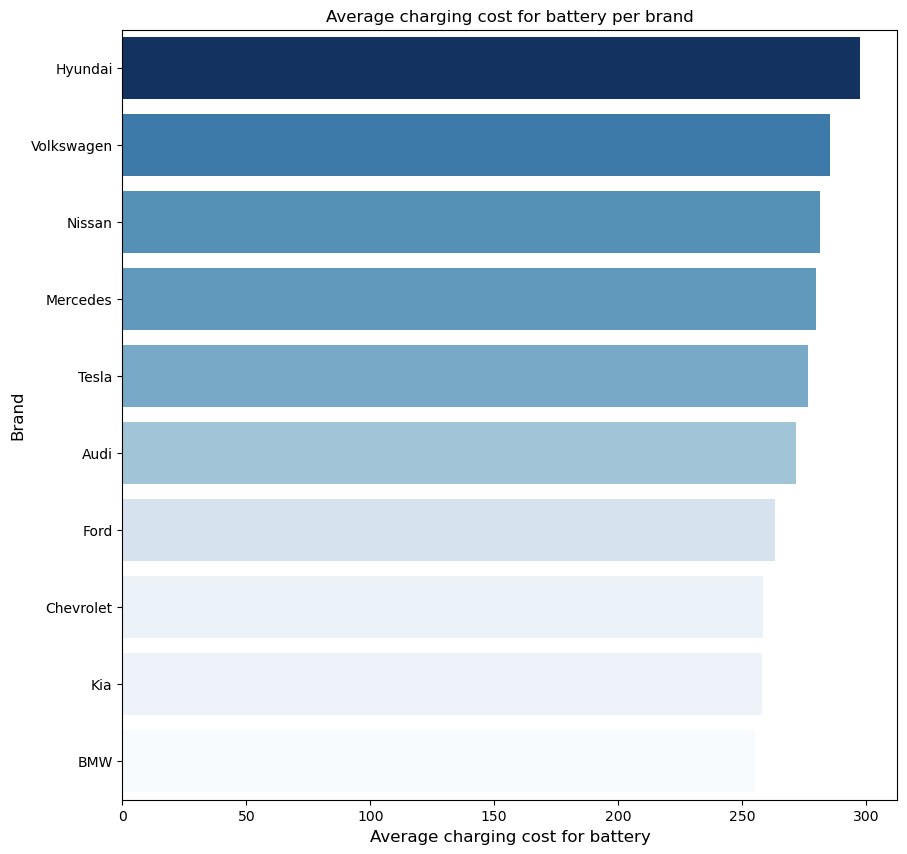

In [142]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_charging_cost, y = Average_charging_cost['Brand'], x = Average_charging_cost['Average charging cost'], 
           palette = 'Blues', hue = 'Average charging cost')
plt.xlabel('Average charging cost for battery', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average charging cost for battery per brand')
plt.show()

## Insights:
- Hyundai has the highest average charging cost for battery.
- Followed by: Volkswagen, Nissan, Mercedes, Tesla.
- Audi has lower average charging cost for battery than Hyundai, Volkswagen, Nissan, Mercedes and Tesla.
- But Audi has higher average charging cost for battery than Ford, Chevrolet, Kia and BMW.
## Conclusions:
- Charging costs vary significantly across brands.
- Hyundai and Volkswagen may offer strong battery performance but at a higher operational cost.
- BMW, Kia, Chevrolet, and Ford provide more economical charging, potentially appealing batteries for everyday use for the the middle class.
- Tesla has moderate average charging cost.

## Goal 5: Average accleleration

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Vehicle_ID                        3000 non-null   int64  
 1   Brand                             3000 non-null   object 
 2   Year                              3000 non-null   int64  
 3   Region                            3000 non-null   object 
 4   Vehicle_Type                      3000 non-null   object 
 5   Battery_Capacity_kWh              3000 non-null   float64
 6   Battery_Health_%                  3000 non-null   float64
 7   Range_km                          3000 non-null   int64  
 8   Charging_Power_kW                 3000 non-null   float64
 9   Charging_Time_hr                  3000 non-null   float64
 10  Charge_Cycles                     3000 non-null   int64  
 11  Energy_Consumption_kWh_per_100km  3000 non-null   float64
 12  Mileag

In [167]:
performance = df.groupby('Brand')[['Acceleration_0_100_kmh_sec', 'Mileage_km', 'Avg_Speed_kmh', 'Max_Speed_kmh']].mean().round(1).reset_index()

In [169]:
performance

,Brand,Acceleration_0_100_kmh_sec,Mileage_km,Avg_Speed_kmh,Max_Speed_kmh
0,Audi,6.7,120740.3,68.8,192.8
1,BMW,6.9,127048.6,66.5,189.0
2,Chevrolet,6.7,126802.1,65.2,191.2
3,Ford,6.7,120625.3,64.4,190.1
4,Hyundai,6.8,131762.3,64.3,187.8
5,Kia,6.4,120730.4,65.7,191.5
6,Mercedes,6.8,122345.8,64.7,190.7
7,Nissan,6.8,127948.1,67.1,190.4
8,Tesla,6.6,120153.0,64.9,191.8
9,Volkswagen,6.8,133389.3,65.3,191.6


In [175]:
Average_accleration = performance[['Brand', 'Acceleration_0_100_kmh_sec']].sort_values(by = 'Acceleration_0_100_kmh_sec', ascending = False)

In [177]:
Average_accleration

,Brand,Acceleration_0_100_kmh_sec
1,BMW,6.9
4,Hyundai,6.8
6,Mercedes,6.8
7,Nissan,6.8
9,Volkswagen,6.8
0,Audi,6.7
2,Chevrolet,6.7
3,Ford,6.7
8,Tesla,6.6
5,Kia,6.4


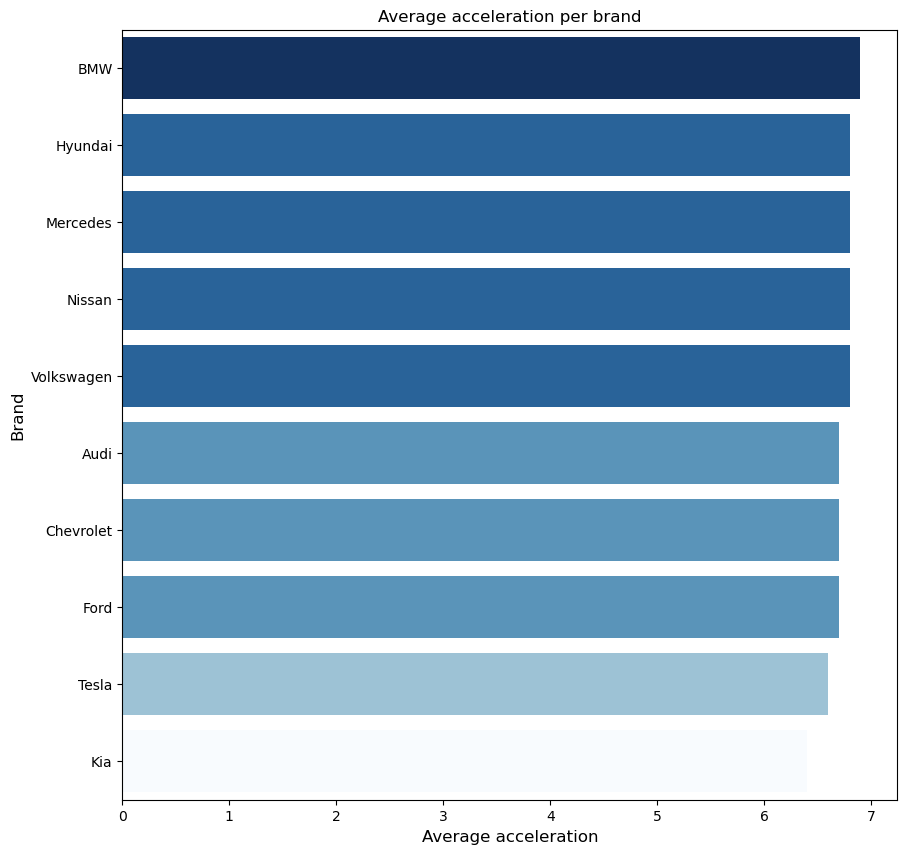

In [181]:
plt.figure(figsize = (10, 10))
sns.barplot(data = Average_accleration, y = Average_accleration['Brand'], x = Average_accleration['Acceleration_0_100_kmh_sec'], 
           palette = 'Blues', hue = 'Acceleration_0_100_kmh_sec')
plt.xlabel('Average acceleration', size = 12)
plt.ylabel('Brand', size = 12)
plt.legend([], [], frameon = False)
plt.title('Average acceleration per brand')
plt.show()

## Conclusions:
- All electric car brands makes vehicles with slightly the same average accleration with BMW taking the lead.
- Tesla and Kia have lower average acceleration.